# Import Required Libraries
Import the necessary libraries, including pandas, numpy, chemotools, and scikit-learn.

In [2]:
!python -m pip install chemotools


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_predict, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
from chemotools.derivative import SavitzkyGolay
from chemotools.scatter import StandardNormalVariate
from chemotools.feature_selection import RangeCut
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA 
from sklearn.cross_decomposition import PLSRegression

# Load Data and first Visualisation
Load the Combined data from the CSV files using pandas.

In [28]:
# Load the combined dataset
combined_data = pd.read_csv('combined_data.csv', sep=',',index_col=0)

# Separate spectral variables and target labels
wavelengths = combined_data.columns[:-1].astype(float)
labels = combined_data['class']

print('Dimensions du dataset complet :', combined_data.shape)
print('Dimensions des spectres :', wavelengths.shape)
print('\nAperçu des classes :')
print(labels.head())

combined_data.head()

Dimensions du dataset complet : (160, 224)
Dimensions des spectres : (223,)

Aperçu des classes :
397.66
0.160989    canola
0.157316    canola
0.180705    canola
0.159618    canola
0.147031    canola
Name: class, dtype: str


,400.28,402.9,405.52,408.13,410.75,413.37,416.0,418.62,421.24,423.86,...,981.27,984.09,986.9,989.72,992.54,995.35,998.17,1000.99,1003.81,class
397.66,,,,,,,,,,,,,,,,,,,,,
0.160989,0.152837,0.143099,0.132230,0.121732,0.113088,0.106684,0.102206,0.097464,0.094226,0.091679,...,0.268508,0.268674,0.268942,0.269235,0.269651,0.270141,0.270695,0.271260,0.271902,canola
0.157316,0.148315,0.139275,0.129330,0.120090,0.112003,0.105155,0.100885,0.097040,0.093725,0.090872,...,0.277404,0.277630,0.277895,0.278252,0.278681,0.279293,0.279852,0.280512,0.281131,canola
0.180705,0.171157,0.159826,0.147212,0.136382,0.126773,0.119723,0.115086,0.109832,0.105594,0.102546,...,0.304266,0.304477,0.304762,0.305169,0.305732,0.306397,0.307044,0.307668,0.308387,canola
0.159618,0.151638,0.141948,0.131743,0.121592,0.112819,0.106271,0.101794,0.097496,0.094452,0.092282,...,0.270041,0.270336,0.270555,0.270984,0.271544,0.272093,0.272727,0.273407,0.274073,canola
0.147031,0.139998,0.130906,0.121395,0.112400,0.104592,0.098618,0.095303,0.091420,0.088122,0.085231,...,0.247827,0.248123,0.248419,0.248833,0.249397,0.249951,0.250570,0.251253,0.251939,canola


In [14]:
#Explore 
print(f"The combined dataset has {combined_data.shape[0]} samples") 
print(f"The combined dataset has {combined_data.shape[1]} features") 

The combined dataset has 160 samples
The combined dataset has 224 features


Text(0.5, 1.0, 'Number of samples per class')

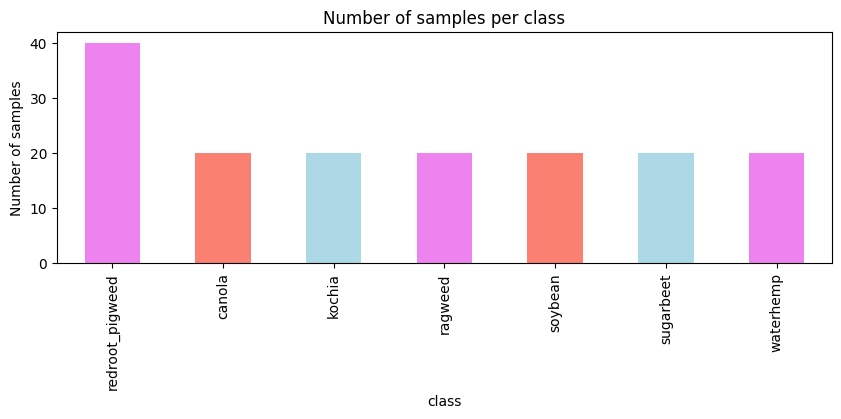

In [17]:
#plot the sample sizes

fig, ax = plt.subplots(figsize=(10, 3)) 
labels.value_counts().plot.bar(color=['Violet', 'Salmon', 'LightBlue'], ax=ax) 
ax.set_ylabel("Number of samples") 
ax.set_title("Number of samples per class") 


In [16]:
color_dict = { "biotic": "Violet", "abiotic": "Salmon", "healthy": "LightBlue" } 
labels.iloc[1]

'canola'

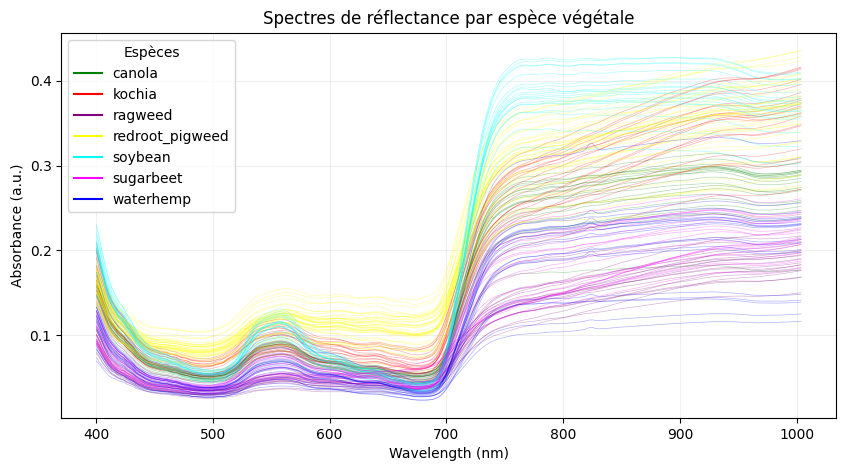

In [60]:
# 1. Dictionnaire de couleurs
color_dict = {
    "canola": "green",
    "kochia": "red",
    "ragweed": "purple",
    "waterhemp": "blue",
    "redroot_pigweed": "yellow",
    "soybean": "cyan",       
    "sugarbeet": "magenta"
}

fig, ax = plt.subplots(figsize=(10, 5))

# 3. On trace par groupe (plus rapide et permet de gérer la légende)
for plante, group in combined_data.groupby('class'):
    color = color_dict.get(plante, "black")
    
    # On trace tous les spectres de cette espèce d'un coup
    # .T (transpose) est nécessaire car matplotlib trace les colonnes
    ax.plot(wavelengths, group.iloc[:, :-1].T, color=color, alpha=0.3, linewidth=0.5)
    
    # On ajoute une ligne vide juste pour créer une entrée dans la légende
    ax.plot([], [], color=color, label=plante)

# Configuration des axes
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Absorbance (a.u.)")
ax.set_title("Spectres de réflectance par espèce végétale")
ax.legend(title="Espèces", loc='upper left')

# Ajout d'une grille pour mieux lire les pics
ax.grid(True, alpha=0.2)

plt.show()

In [47]:
# get the values of the spectra and classes
X = wavelengths.values
X_X = combined_data.iloc[:, :-1].values
# Make a LabelEncoder object 
le = LabelEncoder() 
# Fit the LabelEncoder object 
le.fit(labels.values.ravel()) 
# Transform the labels 
labels_encoded = le.transform(labels.values.ravel()) 
print(labels_encoded)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 4 4 4 4 4 4 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 6 6 6 6 6 6 6 6
 6 6 6 6 6 6 6 6 6 6 6 6]


In [38]:
# Make a OneHotEncoder object 
enc = OneHotEncoder(handle_unknown='ignore')

# CORRECTION : On transforme le tableau 1D en tableau 2D (1 colonne)
labels_2d = labels.values.reshape(-1, 1)

# Fit et Transform en une seule étape (plus efficace)
labels_dummy = enc.fit_transform(labels_2d).toarray()

print("Matrice One-Hot :")
print(labels_dummy)

print("\nTest de transformation inverse :")
print(enc.inverse_transform(labels_dummy))

Matrice One-Hot :
[[1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 0. 0. 1.]]

Test de transformation inverse :
[['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['canola']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['kochia']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['ragweed']
 ['redroot_pigweed']
 ['redroot_pigweed']
 ['redroot

# PCA

Text(0.5, 1.0, 'PCA scores')

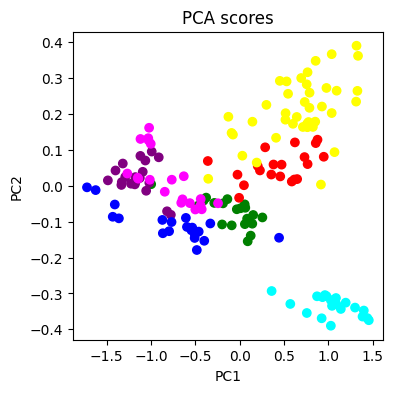

In [61]:
# standardize the data 
spectra_scaled = StandardScaler(with_std=False).fit_transform(X_X) 
# make a PCA object 
pca = PCA(n_components=2) 
# fit and transform the data 
spectra_pca = pca.fit_transform(spectra_scaled) 
# Make a dataframe with the PCA scores 
spectra_pca_df = pd.DataFrame(data=spectra_pca, columns=["PC1", "PC2"], index=combined_data.index) 
# Add the labels to the dataframe 
spectra_pca_df = pd.concat([spectra_pca_df, labels], axis=1) 
# Plot the PCA scores 
fig, ax = plt.subplots(figsize=(4, 4)) 
ax.scatter(spectra_pca_df["PC1"], spectra_pca_df["PC2"], c=spectra_pca_df["class"].map(color_dict)) 
ax.set_xlabel("PC1") 
ax.set_ylabel("PC2") 
ax.set_title("PCA scores") 

# Preprocess Data
## Aim of the Data Pre-Processing

-   **Noisy signal**: this noise may be due to measurement or environmental error. The simplest way to eliminate it is to make *m*
    repeated measurements of the spectrum per individual and then calculate an average spectrum per individual.

-   **Signal derivatives**: Using spectrum derivatives can remove additive (measurement bias) or multiplicative effects.

-   **Individual variations**: the dispersion of spectrum measurements between individuals may be due to light scattering and variations in
    the effective wavelength. The simplest way to reduce these variations is to centre and reduce the spectrum data for each
    individual.

-   **Normalise each wavelength**: we can use the raw values of the wavelengths but it is recommanded to centre and reduce each wavelength before the PLS.

## Preprocess the spectra data using chemotools' Savitzky-Golay filter.

In [68]:
# Create a preprocessing pipeline
pipeline = make_pipeline(
    StandardNormalVariate(),
    SavitzkyGolay(window_size=21, 
                  polynomial_order=11,
                  derivate_order=3),
#    RangeCut(start=0, end=190),
#    StandardScaler(with_std=False)
)
preprocessed_spectra = pipeline.fit_transform(X_X) 


c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:907: FutureWarning: `window_size` is deprecated and will be removed in a future release. Use `window_length` instead.
  return self.fit(X, **fit_params).transform(X)
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:907: FutureWarning: `polynomial_order` is deprecated and will be removed in a future release. Use `polyorder` instead.
  return self.fit(X, **fit_params).transform(X)
c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py:907: FutureWarning: `derivate_order` is deprecated and will be removed in a future release. Use `deriv` instead.
  return self.fit(X, **fit_params).transform(X)


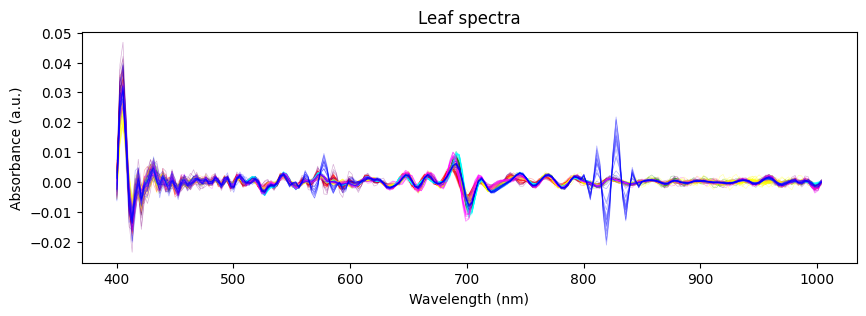

In [74]:
# Let's plot the preprocessed spectra to see the effect of the preprocessing steps. 
fig, ax = plt.subplots(figsize=(10, 3)) 
for i, spectrum in enumerate(preprocessed_spectra): 
    # On récupère le nom de la plante
    plante = labels.iloc[i]
    # On récupère sa couleur de manière sécurisée
    couleur = color_dict.get(plante, "black")
    ax.plot(wavelengths, spectrum, color=couleur, alpha=0.3, linewidth=0.5)
# On configure les axes en dehors de la boucle
ax.set_xlabel("Wavelength (nm)") 
ax.set_ylabel("Absorbance (a.u.)") 
ax.set_title("Leaf spectra") 

plt.show()